# 06 Evaluation

Objective: expand model evaluation beyond R2 by summarizing MAE, RMSE, MAPE, and MdAPE overall and across important market/property segments.

This notebook uses saved row-level final-test predictions from earlier notebooks and focuses on:
- overall metric comparison across Linear Regression, Decision Tree, Random Forest, and XGBoost
- target comparison for XGBoost raw vs. log1p predictions
- price band, geography, size, age, missingness, and prediction-direction error summaries
- manual review files for the largest absolute errors
- presentation-ready charts for model comparison and segment-level error patterns

Deliverables: `outputs/week8_evaluation/metrics_summary.csv` and presentation figures under `outputs/week8_evaluation/figures/`.


## 0. Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=UserWarning)

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "idx-california-price-prediction",
]
PROJECT_ROOT = next(
    root for root in candidate_roots
    if (root / "data" / "processed").exists() and (root / "notebooks").exists()
)
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
ENGINEERED_SPLIT_DIR = PROCESSED_DATA_DIR / "week6_feature_engineering" / "splits"
TEST_CSV = ENGINEERED_SPLIT_DIR / "test_latest_month_engineered.csv"

WEEK6_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week6_feature_engineering"
WEEK7_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week7_advanced_models"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "week8_evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Evaluation output directory: {OUTPUT_DIR}")

Project root: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction
Evaluation output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation


## 1. Load Predictions and Test Features

Load final-test row-level predictions saved by Week 6 and Week 7. Week 6 selected-model predictions provide Linear Regression, Decision Tree, and Random Forest comparisons. Week 7 by-target predictions provide XGBoost raw and log1p variants.

In [2]:
CATEGORICAL_DTYPE_COLS = [
    "City",
    "CountyOrParish",
    "PostalCode",
    "MLSAreaMajor",
    "Levels",
    "HighSchoolDistrict",
    "UnifiedSchoolDistrict",
]


def normalize_categorical_dtypes(df):
    for col in CATEGORICAL_DTYPE_COLS:
        if col in df.columns:
            df[col] = df[col].astype("string").fillna("__missing__")
    return df


def load_split_file(path):
    df = normalize_categorical_dtypes(pd.read_csv(path, low_memory=False))
    if "CloseDate" in df.columns:
        df["CloseDate"] = pd.to_datetime(df["CloseDate"], errors="coerce")
    if "close_month" in df.columns:
        df["close_month"] = pd.PeriodIndex(df["close_month"], freq="M")
    return df


MODEL_LABEL_MAP = {
    "LinearRegression": "LinearRegression",
    "DecisionTreeRegressor": "DecisionTree",
    "RandomForestRegressor": "RandomForest",
}
MODEL_ORDER = [
    "LinearRegression",
    "DecisionTree",
    "RandomForest",
    "XGBoost_log1p",
    "XGBoost_raw",
]
METRIC_DISPLAY_COLS = ["model_label", "r2", "mae", "rmse", "mape", "mdape"]
SEGMENT_DISPLAY_COLS = ["model_label", "segment_value", "count", "r2", "mae", "rmse", "mape", "mdape"]
SUMMARY_OUTPUT_COLS = ["model_label", "segment_type", "segment_value", "count", "r2", "mae", "rmse", "mape", "mdape"]


def make_short_model_label(row):
    model_name = str(row["model"])
    target_transform = str(row.get("target_transform", "raw"))
    if model_name == "XGBoost":
        return f"XGBoost_{target_transform}"
    return MODEL_LABEL_MAP.get(model_name, model_name.replace("Regressor", ""))


def normalize_prediction_frame(df, source_name):
    result = df.copy()
    if "target_transform" not in result.columns:
        result["target_transform"] = "raw"
    if "configuration" not in result.columns:
        result["configuration"] = result.get("evaluation_role", "final_test")
    if "feature_set" not in result.columns:
        result["feature_set"] = "unknown"
    if "selected_target_transform" not in result.columns:
        result["selected_target_transform"] = pd.NA
    result["source_name"] = source_name
    result["model_label"] = result.apply(make_short_model_label, axis=1)
    return result


prediction_sources = []

week6_predictions_path = WEEK6_OUTPUT_DIR / "final_base_vs_selected_feature_predictions.csv"
if week6_predictions_path.exists():
    week6_predictions = pd.read_csv(week6_predictions_path, low_memory=False)
    week6_predictions = week6_predictions[week6_predictions["evaluation_role"].eq("Selected New")].copy()
    prediction_sources.append(normalize_prediction_frame(week6_predictions, "week6_selected_models"))
else:
    print(f"Missing Week 6 predictions: {week6_predictions_path}")

xgboost_by_target_path = WEEK7_OUTPUT_DIR / "test_predictions_xgboost_by_target.csv"
if xgboost_by_target_path.exists():
    xgb_predictions = pd.read_csv(xgboost_by_target_path, low_memory=False)
    prediction_sources.append(normalize_prediction_frame(xgb_predictions, "week7_xgboost_by_target"))
else:
    xgboost_selected_path = WEEK7_OUTPUT_DIR / "test_predictions_xgboost.csv"
    if xgboost_selected_path.exists():
        xgb_predictions = pd.read_csv(xgboost_selected_path, low_memory=False)
        prediction_sources.append(normalize_prediction_frame(xgb_predictions, "week7_xgboost_selected"))
    else:
        print(f"Missing Week 7 XGBoost predictions: {xgboost_by_target_path}")

if not prediction_sources:
    raise FileNotFoundError("No row-level prediction files found for evaluation.")

predictions_df = pd.concat(prediction_sources, ignore_index=True, sort=False)
predictions_df["model_label"] = pd.Categorical(predictions_df["model_label"], categories=MODEL_ORDER, ordered=True)

for col in ["ClosePrice", "predicted_ClosePrice", "residual", "absolute_error", "absolute_percentage_error"]:
    predictions_df[col] = pd.to_numeric(predictions_df[col], errors="coerce")

predictions_df["residual"] = predictions_df["ClosePrice"] - predictions_df["predicted_ClosePrice"]
predictions_df["absolute_error"] = predictions_df["residual"].abs()
predictions_df["absolute_percentage_error"] = predictions_df["absolute_error"] / predictions_df["ClosePrice"] * 100
predictions_df["signed_percentage_error"] = predictions_df["residual"] / predictions_df["ClosePrice"] * 100

test_features_df = load_split_file(TEST_CSV)

print(f"Prediction rows: {len(predictions_df):,}")
print(f"Models loaded: {predictions_df['model_label'].nunique()}")
display(predictions_df[["model_label", "model", "target_transform"]].drop_duplicates().sort_values("model_label"))

Prediction rows: 62,690
Models loaded: 5


,model_label,model,target_transform
0,LinearRegression,LinearRegression,raw
12538,DecisionTree,DecisionTreeRegressor,raw
25076,RandomForest,RandomForestRegressor,raw
50152,XGBoost_log1p,XGBoost,log1p
37614,XGBoost_raw,XGBoost,raw


## 2. Add Evaluation Segments

Merge engineered test features into the prediction rows and create reusable segment labels for price band, geography, size, age, missingness, and prediction direction.

In [3]:
feature_detail_cols = [
    "ListingKey",
    "PostalCode",
    "City",
    "CountyOrParish",
    "MLSAreaMajor",
    "HighSchoolDistrict",
    "UnifiedSchoolDistrict",
    "LivingArea",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "YearBuilt",
    "PropertyAgeYears",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Levels",
    "PoolPrivateYN",
    "ViewYN",
    "AssociationFee",
    "DaysOnMarket",
]
missing_flag_cols = [col for col in test_features_df.columns if col.endswith("_missing")]
quality_flag_cols = [
    "invalid_coordinates_flag",
    "PostalCode_format_issue_flag",
    "lot_size_unit_mismatch_flag",
    "lot_size_sqft_derived_from_acres_flag",
    "listing_after_purchase_flag",
    "purchase_after_close_flag",
    "listing_after_close_flag",
    "negative_days_on_market_flag",
    "date_order_issue_flag",
]
feature_detail_cols = [col for col in feature_detail_cols if col in test_features_df.columns]
quality_flag_cols = [col for col in quality_flag_cols if col in test_features_df.columns]

evaluation_df = predictions_df.merge(
    test_features_df[feature_detail_cols + missing_flag_cols + quality_flag_cols],
    on="ListingKey",
    how="left",
    suffixes=("", "_feature"),
)

evaluation_df["missing_feature_count"] = (
    evaluation_df[missing_flag_cols].fillna(0).astype(float).sum(axis=1)
    if missing_flag_cols else 0
)
evaluation_df["quality_flag_count"] = (
    evaluation_df[quality_flag_cols].fillna(0).astype(float).sum(axis=1)
    if quality_flag_cols else 0
)

price_quintile_lookup = (
    test_features_df[["ListingKey", "ClosePrice"]]
    .assign(ClosePrice_quintile=lambda df: pd.qcut(
        df["ClosePrice"],
        q=5,
        labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"],
        duplicates="drop",
    ))[["ListingKey", "ClosePrice_quintile"]]
)
evaluation_df = evaluation_df.drop(columns=["ClosePrice_quintile"], errors="ignore").merge(
    price_quintile_lookup,
    on="ListingKey",
    how="left",
)

evaluation_df["price_extreme_band"] = np.select(
    [
        evaluation_df["ClosePrice_quintile"].astype("string").eq("Q1 lowest"),
        evaluation_df["ClosePrice_quintile"].astype("string").eq("Q5 highest"),
    ],
    ["Low price: bottom quintile", "High price: top quintile"],
    default="Middle price: Q2-Q4",
)

evaluation_df["LivingArea_bin"] = pd.cut(
    evaluation_df["LivingArea"],
    bins=[0, 1000, 1500, 2000, 3000, 5000, np.inf],
    labels=["<=1,000", "1,001-1,500", "1,501-2,000", "2,001-3,000", "3,001-5,000", ">5,000"],
    include_lowest=True,
)

evaluation_df["PropertyAgeYears_bin"] = pd.cut(
    evaluation_df["PropertyAgeYears"],
    bins=[-np.inf, 0, 5, 15, 30, 50, 75, 100, np.inf],
    labels=["0", "1-5", "6-15", "16-30", "31-50", "51-75", "76-100", ">100"],
)

evaluation_df["missing_feature_count_bin"] = pd.cut(
    evaluation_df["missing_feature_count"],
    bins=[-0.1, 0, 1, 3, 5, np.inf],
    labels=["0", "1", "2-3", "4-5", ">5"],
)

evaluation_df["prediction_direction"] = np.select(
    [evaluation_df["residual"] > 0, evaluation_df["residual"] < 0],
    ["Underpredicted", "Overpredicted"],
    default="Exact",
)

evaluation_df["large_error_direction"] = "Not top absolute-error rows"
for model_label, model_df in evaluation_df.groupby("model_label"):
    threshold = model_df["absolute_error"].nlargest(min(100, len(model_df))).min()
    model_mask = evaluation_df["model_label"].eq(model_label) & evaluation_df["absolute_error"].ge(threshold)
    evaluation_df.loc[model_mask & evaluation_df["residual"].gt(0), "large_error_direction"] = "Largest errors: underpredicted"
    evaluation_df.loc[model_mask & evaluation_df["residual"].lt(0), "large_error_direction"] = "Largest errors: overpredicted"

evaluation_df.to_csv(OUTPUT_DIR / "evaluation_prediction_detail.csv", index=False)

print(f"Evaluation detail rows: {len(evaluation_df):,}")
print(f"Saved detail: {OUTPUT_DIR / 'evaluation_prediction_detail.csv'}")

Evaluation detail rows: 62,690
Saved detail: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/evaluation_prediction_detail.csv


## 3. Overall Metrics Summary

Compute R2 plus MAE, RMSE, MAPE, and MdAPE for each final-test prediction set.

In [4]:
def regression_metrics_for_frame(df):
    y_true = df["ClosePrice"].astype(float)
    y_pred = df["predicted_ClosePrice"].astype(float)
    ape = ((y_true - y_pred).abs() / y_true).replace([np.inf, -np.inf], np.nan) * 100
    if len(df) >= 2 and y_true.nunique(dropna=True) > 1:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan
    return pd.Series({
        "count": len(df),
        "median_actual_price": y_true.median(),
        "median_predicted_price": y_pred.median(),
        "mean_residual": (y_true - y_pred).mean(),
        "r2": r2,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": ape.mean(),
        "mdape": ape.median(),
    })


def summarize_by_segment(df, segment_col, min_count=1):
    group_cols = [
        "model",
        "configuration",
        "target_transform",
        "feature_set",
        "model_label",
        segment_col,
    ]
    summary = (
        df.dropna(subset=[segment_col])
        .groupby(group_cols, observed=True)
        .apply(regression_metrics_for_frame)
        .reset_index()
        .rename(columns={segment_col: "segment_value"})
    )
    summary = summary[summary["count"] >= min_count].copy()
    summary["segment_type"] = segment_col
    return summary


overall_summary = (
    evaluation_df
    .groupby(["model", "configuration", "target_transform", "feature_set", "model_label"], observed=True)
    .apply(regression_metrics_for_frame)
    .reset_index()
)
overall_summary["segment_type"] = "overall"
overall_summary["segment_value"] = "overall"

metrics_summary_parts = [overall_summary]

segment_specs = {
    "ClosePrice_quintile": 1,
    "price_extreme_band": 1,
    "CountyOrParish": 20,
    "PostalCode": 10,
    "UnifiedSchoolDistrict": 10,
    "LivingArea_bin": 1,
    "PropertyAgeYears_bin": 1,
    "missing_feature_count_bin": 1,
    "prediction_direction": 1,
    "large_error_direction": 1,
}

for segment_col, min_count in segment_specs.items():
    metrics_summary_parts.append(summarize_by_segment(evaluation_df, segment_col, min_count=min_count))

metrics_summary_df = pd.concat(metrics_summary_parts, ignore_index=True, sort=False)
metrics_summary_df = metrics_summary_df[[
    "model",
    "configuration",
    "target_transform",
    "feature_set",
    "model_label",
    "segment_type",
    "segment_value",
    "count",
    "median_actual_price",
    "median_predicted_price",
    "mean_residual",
    "r2",
    "mae",
    "rmse",
    "mape",
    "mdape",
]]
metrics_summary_df["model_label"] = pd.Categorical(metrics_summary_df["model_label"], categories=MODEL_ORDER, ordered=True)
metrics_summary_df = metrics_summary_df.sort_values(["model_label", "segment_type", "segment_value"]).reset_index(drop=True)
metrics_summary_df[SUMMARY_OUTPUT_COLS].to_csv(OUTPUT_DIR / "metrics_summary.csv", index=False)

overall_summary["model_label"] = pd.Categorical(overall_summary["model_label"], categories=MODEL_ORDER, ordered=True)
display(overall_summary.sort_values("model_label")[METRIC_DISPLAY_COLS].round(4))
print(f"Saved metrics summary: {OUTPUT_DIR / 'metrics_summary.csv'}")


,model_label,r2,mae,rmse,mape,mdape
1,LinearRegression,0.8552,215528.1873,364204.4819,19.5947,14.3444
0,DecisionTree,0.7641,226461.2179,464915.6746,16.3086,10.8435
2,RandomForest,0.8901,157781.2308,317251.0829,11.6415,7.6041
3,XGBoost_log1p,0.9087,148075.0993,289276.1335,10.8434,7.6545
4,XGBoost_raw,0.9081,152226.5920,290186.2528,11.6870,8.1097


Saved metrics summary: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/metrics_summary.csv


## 4. Price Band Insights

Summarize which price bands perform better or worse. The Week 8 prompt specifically asks for insights such as price-band performance.

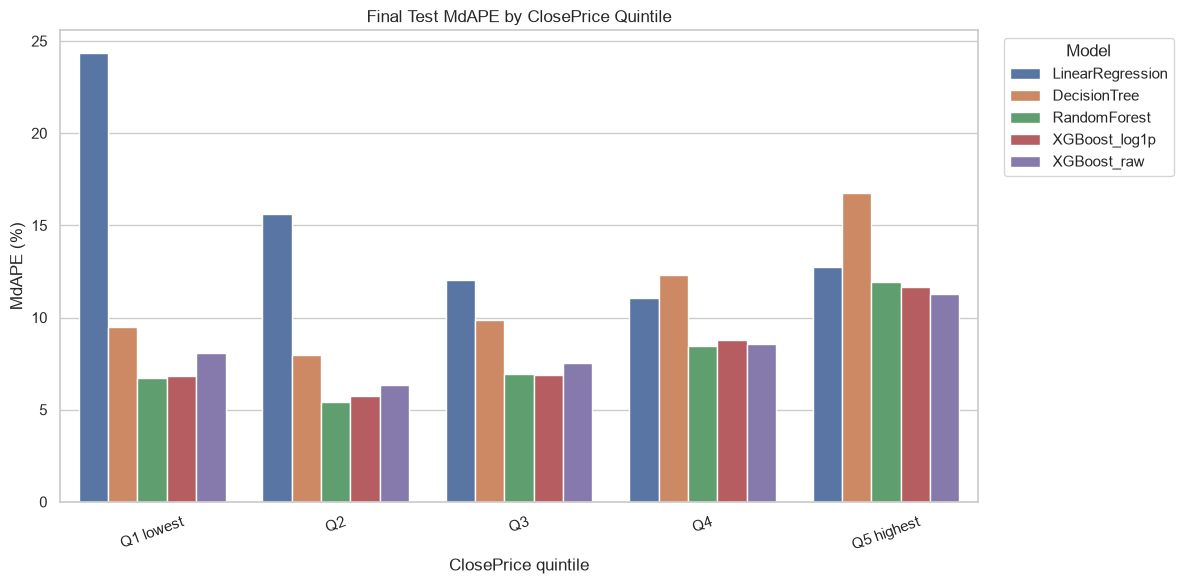

In [5]:
price_band_summary = metrics_summary_df[
    metrics_summary_df["segment_type"].isin(["ClosePrice_quintile", "price_extreme_band"])
].copy()
price_band_summary.to_csv(OUTPUT_DIR / "price_band_metrics_summary.csv", index=False)


plt.figure(figsize=(12, 6))
sns.barplot(
    data=price_band_summary[price_band_summary["segment_type"] == "ClosePrice_quintile"],
    x="segment_value",
    y="mdape",
    hue="model_label",
    hue_order=MODEL_ORDER,
)
plt.title("Final Test MdAPE by ClosePrice Quintile")
plt.xlabel("ClosePrice quintile")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=20)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5. Geography Insights

Keep the geography analysis focused for presentation. The full summary still includes county, postal code, and school district metrics, but the notebook discussion highlights county-level error patterns and a few luxury ZIP-code examples.


In [6]:
geography_summary = metrics_summary_df[
    metrics_summary_df["segment_type"].isin(["CountyOrParish", "PostalCode", "UnifiedSchoolDistrict"])
].copy()
geography_summary[["segment_type"] + SEGMENT_DISPLAY_COLS].to_csv(OUTPUT_DIR / "geography_metrics_summary.csv", index=False)

available_geography_models = geography_summary["model_label"].astype(str).unique().tolist()
geography_focus_model = "XGBoost_log1p" if "XGBoost_log1p" in available_geography_models else available_geography_models[0]
print(f"Geography focus model: {geography_focus_model}")

county_table = (
    geography_summary[
        geography_summary["segment_type"].eq("CountyOrParish")
        & geography_summary["model_label"].astype(str).eq(geography_focus_model)
    ]
    .sort_values("mae", ascending=False)
    .rename(columns={
        "segment_value": "County",
        "count": "Count",
        "median_actual_price": "Median Price",
        "mae": "MAE",
        "mdape": "MdAPE",
    })
    [["County", "Count", "Median Price", "MAE", "MdAPE"]]
)
county_table.to_csv(OUTPUT_DIR / "county_error_summary.csv", index=False)

print("County-level error summary")
display(
    county_table
    .head(12)
    .style.format({
        "Median Price": "${:,.0f}",
        "MAE": "${:,.0f}",
        "MdAPE": "{:.2f}%",
    })
)

luxury_zip_examples = (
    geography_summary[
        geography_summary["segment_type"].eq("PostalCode")
        & geography_summary["model_label"].astype(str).eq(geography_focus_model)
    ]
    .sort_values(["median_actual_price", "mae"], ascending=[False, False])
    .rename(columns={
        "segment_value": "PostalCode",
        "count": "Count",
        "median_actual_price": "Median Price",
        "mae": "MAE",
        "mdape": "MdAPE",
    })
    [["PostalCode", "Count", "Median Price", "MAE", "MdAPE"]]
    .head(10)
)
luxury_zip_examples.to_csv(OUTPUT_DIR / "luxury_zip_error_examples.csv", index=False)

print("Luxury ZIP examples")
display(
    luxury_zip_examples
    .style.format({
        "Median Price": "${:,.0f}",
        "MAE": "${:,.0f}",
        "MdAPE": "{:.2f}%",
    })
)


Geography focus model: XGBoost_log1p
County-level error summary


,County,Count,Median Price,MAE,MdAPE
2094,San Mateo,199.000000,"$1,885,000","$319,806",11.71%
2097,Santa Cruz,100.000000,"$1,350,000","$272,533",14.08%
2096,Santa Clara,384.000000,"$1,800,000","$262,189",9.35%
2085,Monterey,110.000000,"$900,000","$209,989",10.18%
2076,Alameda,615.000000,"$1,320,000","$204,975",9.64%
2086,Orange,1196.000000,"$1,445,000","$185,411",7.40%
2082,Los Angeles,3021.000000,"$1,050,000","$181,893",8.62%
2095,Santa Barbara,72.000000,"$834,500","$174,140",10.24%
2091,San Diego,1445.000000,"$1,100,000","$171,187",7.90%
2093,San Luis Obispo,209.000000,"$965,000","$164,196",10.17%


Luxury ZIP examples


,PostalCode,Count,Median Price,MAE,MdAPE
2555,95070,11.000000,"$4,760,000","$455,312",5.95%
2134,90265,12.000000,"$4,260,000","$1,017,986",23.01%
2129,90210,13.000000,"$4,050,000","$500,868",10.01%
2135,90266,20.000000,"$3,984,125","$669,017",10.14%
2407,92660,24.000000,"$3,955,000","$591,216",12.58%
2305,92118,11.000000,"$3,571,000","$671,581",16.48%
2487,94010,14.000000,"$3,360,000","$433,052",9.51%
2123,90049,22.000000,"$3,315,000","$712,803",12.94%
2270,92014,11.000000,"$3,250,000","$426,984",9.45%
2136,90272,11.000000,"$3,195,000","$766,103",18.23%


## 6. Property Segment Insights

Check whether errors concentrate in unusually large homes, older homes, or rows with more missing fields.

In [7]:
property_segment_summary = metrics_summary_df[
    metrics_summary_df["segment_type"].isin([
        "LivingArea_bin",
        "PropertyAgeYears_bin",
        "missing_feature_count_bin",
    ])
].copy()
property_segment_summary.to_csv(OUTPUT_DIR / "property_segment_metrics_summary.csv", index=False)

for segment_type in ["LivingArea_bin", "PropertyAgeYears_bin", "missing_feature_count_bin"]:
    print(f"Property segment metrics: {segment_type}")
    display(
        property_segment_summary[property_segment_summary["segment_type"] == segment_type]
        .sort_values(["model_label", "segment_value"])
        [SEGMENT_DISPLAY_COLS]
        .round(2)
    )

Property segment metrics: LivingArea_bin


,model_label,segment_value,count,r2,mae,rmse,mape,mdape
30,LinearRegression,"1,001-1,500",3222.0,0.72,144727.67,202393.74,20.82,15.88
31,LinearRegression,"1,501-2,000",3359.0,0.81,151752.66,217794.14,16.85,12.73
32,LinearRegression,"2,001-3,000",3647.0,0.82,213115.26,326390.82,16.96,12.54
33,LinearRegression,"3,001-5,000",1464.0,0.75,452649.88,664772.76,22.92,17.67
34,LinearRegression,"<=1,000",660.0,0.32,166644.43,241047.02,30.64,21.39
35,LinearRegression,">5,000",173.0,0.62,917826.81,1246315.93,24.15,16.20
720,DecisionTree,"1,001-1,500",3222.0,0.78,114030.15,178245.07,14.27,10.00
721,DecisionTree,"1,501-2,000",3359.0,0.77,145907.23,237678.79,14.07,9.47
722,DecisionTree,"2,001-3,000",3647.0,0.70,242548.66,421525.21,16.65,10.91
723,DecisionTree,"3,001-5,000",1464.0,0.61,519968.67,839426.97,21.56,14.31


Property segment metrics: PropertyAgeYears_bin


,model_label,segment_value,count,r2,mae,rmse,mape,mdape
510,LinearRegression,0,326.0,0.91,209012.96,381809.91,19.17,15.01
511,LinearRegression,1-5,452.0,0.89,235987.45,385670.46,21.16,17.61
512,LinearRegression,16-30,2064.0,0.86,238870.04,402389.97,21.80,16.58
513,LinearRegression,31-50,2914.0,0.86,199980.82,324105.20,20.58,15.05
514,LinearRegression,51-75,4063.0,0.85,191219.31,321606.32,17.26,12.30
515,LinearRegression,6-15,688.0,0.85,259109.53,462832.61,19.27,15.06
516,LinearRegression,76-100,1441.0,0.83,232020.80,400217.29,19.04,13.81
517,LinearRegression,>100,579.0,0.81,267062.12,416463.29,22.06,16.94
1200,DecisionTree,0,326.0,0.89,151821.79,404911.32,8.16,4.37
1201,DecisionTree,1-5,452.0,0.81,225505.24,502794.95,13.62,8.36


Property segment metrics: missing_feature_count_bin


,model_label,segment_value,count,r2,mae,rmse,mape,mdape
679,LinearRegression,0,4157.0,0.85,188089.75,313366.97,19.14,14.17
680,LinearRegression,1,4071.0,0.85,196866.92,335630.21,20.69,15.10
681,LinearRegression,2-3,3887.0,0.85,246254.40,403307.17,18.50,13.60
682,LinearRegression,4-5,417.0,0.82,373433.75,613246.66,20.85,15.43
683,LinearRegression,>5,6.0,0.81,1007564.34,1097903.31,215.77,66.95
1369,DecisionTree,0,4157.0,0.81,172679.98,358218.68,13.62,9.27
1370,DecisionTree,1,4071.0,0.81,188508.85,373034.24,15.78,10.37
1371,DecisionTree,2-3,3887.0,0.69,297995.60,575929.72,19.03,13.02
1372,DecisionTree,4-5,417.0,0.64,461703.53,873443.63,22.51,15.19
1373,DecisionTree,>5,6.0,0.93,546879.17,669500.13,41.83,39.95


## 7. Large Error Review

Save the largest absolute errors, largest underpredictions, and largest overpredictions per model for manual review. These rows help separate data issues from genuine model blind spots.

In [8]:
review_cols = [
    "model",
    "configuration",
    "target_transform",
    "feature_set",
    "model_label",
    "ListingKey",
    "CloseDate",
    "CountyOrParish",
    "City",
    "PostalCode",
    "UnifiedSchoolDistrict",
    "ClosePrice",
    "predicted_ClosePrice",
    "residual",
    "absolute_error",
    "absolute_percentage_error",
    "signed_percentage_error",
    "LivingArea",
    "LotSizeSquareFeet",
    "LotSizeAcres",
    "YearBuilt",
    "PropertyAgeYears",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "GarageSpaces",
    "ParkingTotal",
    "Levels",
    "PoolPrivateYN",
    "ViewYN",
    "AssociationFee",
    "DaysOnMarket",
    "missing_feature_count",
    "quality_flag_count",
]
review_cols = [col for col in review_cols if col in evaluation_df.columns]

top_abs_error_df = (
    evaluation_df
    .sort_values(["model_label", "absolute_error"], ascending=[True, False])
    .groupby("model_label", group_keys=False)
    .head(100)[review_cols]
)
top_underpredicted_df = (
    evaluation_df[evaluation_df["residual"] > 0]
    .sort_values(["model_label", "residual"], ascending=[True, False])
    .groupby("model_label", group_keys=False)
    .head(50)[review_cols]
)
top_overpredicted_df = (
    evaluation_df[evaluation_df["residual"] < 0]
    .sort_values(["model_label", "residual"], ascending=[True, True])
    .groupby("model_label", group_keys=False)
    .head(50)[review_cols]
)

top_abs_error_df.to_csv(OUTPUT_DIR / "top_100_absolute_errors_by_model.csv", index=False)
top_underpredicted_df.to_csv(OUTPUT_DIR / "top_50_underpredictions_by_model.csv", index=False)
top_overpredicted_df.to_csv(OUTPUT_DIR / "top_50_overpredictions_by_model.csv", index=False)

display(top_abs_error_df.groupby("model_label").head(10).round(2))
print(f"Saved top-error review files to: {OUTPUT_DIR}")

,model,configuration,target_transform,feature_set,model_label,ListingKey,CloseDate,CountyOrParish,City,PostalCode,UnifiedSchoolDistrict,ClosePrice,predicted_ClosePrice,residual,absolute_error,absolute_percentage_error,signed_percentage_error,LivingArea,LotSizeSquareFeet,LotSizeAcres,YearBuilt,PropertyAgeYears,BedroomsTotal,BathroomsTotalInteger,GarageSpaces,ParkingTotal,Levels,PoolPrivateYN,ViewYN,AssociationFee,DaysOnMarket,missing_feature_count,quality_flag_count
12370,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1174683372,2026-06-15,Los Angeles,Calabasas,91302,Las Virgenes Unified,8900000.0,3958756.45,4941243.55,4941243.55,55.52,55.52,5968.0,26157.0,0.60,2006.0,20.0,5.0,6.0,NaN,0.0,Two,1.0,1.0,417.00,0,1.0,0.0
2020,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1154752320,2026-06-01,Riverside,Rancho Mirage,92270,Palm Springs Unified,7000000.0,2728162.62,4271837.38,4271837.38,61.03,61.03,4900.0,32670.0,0.75,1957.0,69.0,5.0,6.0,2.0,4.0,One,1.0,1.0,688.00,46,0.0,0.0
10710,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1168543834,2026-06-22,San Diego,Solana Beach,92075,__missing__,8495000.0,4519095.96,3975904.04,3975904.04,46.80,46.80,5348.0,NaN,NaN,2013.0,13.0,4.0,4.0,2.0,8.0,One,0.0,0.0,NaN,16,4.0,0.0
10319,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1165484215,2026-06-24,Riverside,La Quinta,92253,Coachella Valley Unified,6410000.0,2558562.48,3851437.52,3851437.52,60.08,60.08,4752.0,16553.0,0.38,2008.0,18.0,4.0,4.0,3.0,6.0,Two,1.0,1.0,900.00,38,0.0,0.0
4701,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1157495415,2026-06-11,Los Angeles,Sherman Oaks,91423,Los Angeles Unified,7585000.0,3932224.16,3652775.84,3652775.84,48.16,48.16,5682.0,59507.0,1.37,1952.0,74.0,5.0,5.0,2.0,10.0,One,1.0,1.0,NaN,31,1.0,0.0
2016,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1154746020,2026-06-26,Los Angeles,Long Beach,90803,Long Beach Unified,5661935.5,2249052.07,3412883.43,3412883.43,60.28,60.28,3000.0,3483.0,0.08,1950.0,76.0,3.0,3.0,2.0,2.0,Two,0.0,1.0,0.00,87,0.0,0.0
1691,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1153753974,2026-06-05,Los Angeles,Malibu,90265,Santa Monica-Malibu Unified,7650000.0,4301460.27,3348539.73,3348539.73,43.77,43.77,4733.0,46167.0,1.06,1976.0,50.0,4.0,5.0,NaN,6.0,Two,1.0,1.0,NaN,67,3.0,0.0
3522,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1156462927,2026-06-29,Los Angeles,Pasadena,91106,Pasadena Unified,8800000.0,5514732.59,3285267.41,3285267.41,37.33,37.33,6977.0,54268.0,1.25,1951.0,75.0,6.0,9.0,4.0,4.0,One,1.0,1.0,0.00,69,0.0,0.0
9048,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1159699268,2026-06-26,Santa Clara,Los Gatos,95032,__missing__,7800000.0,4559404.48,3240595.52,3240595.52,41.55,41.55,4661.0,21125.0,0.48,1968.0,58.0,5.0,5.0,3.0,6.0,__missing__,NaN,1.0,NaN,32,3.0,0.0
9874,LinearRegression,Selected New,raw,Base + Structural Derived + UnifiedSchoolDistrict,LinearRegression,1159997722,2026-06-18,Los Angeles,Manhattan Beach,90266,Manhattan Beach Unified,7400000.0,4281047.15,3118952.85,3118952.85,42.15,42.15,4098.0,2710.0,0.06,2002.0,24.0,5.0,5.0,3.0,3.0,ThreeOrMore,0.0,1.0,0.00,6,1.0,0.0


Saved top-error review files to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation


## 8. Manual Review Flags

Create coarse flags for the top 100 absolute-error rows per model. These flags are not final diagnoses; they help triage whether errors look like luxury-market scarcity, size/lot anomalies, missingness, or data-quality issues.

In [9]:
manual_review_flags = evaluation_df.copy()
manual_review_flags["possible_luxury_or_sparse_high_price"] = manual_review_flags["ClosePrice_quintile"].astype("string").eq("Q5 highest")
manual_review_flags["possible_large_lot_issue"] = manual_review_flags["LotSizeSquareFeet"].gt(manual_review_flags["LotSizeSquareFeet"].quantile(0.99))
manual_review_flags["possible_living_area_issue"] = (
    manual_review_flags["LivingArea"].isna()
    | manual_review_flags["LivingArea"].lt(300)
    | manual_review_flags["LivingArea"].gt(manual_review_flags["LivingArea"].quantile(0.995))
)
manual_review_flags["possible_missingness_issue"] = manual_review_flags["missing_feature_count"] >= 4
manual_review_flags["possible_quality_flag_issue"] = manual_review_flags["quality_flag_count"] > 0
manual_review_flags["model_pulled_toward_mean"] = (
    manual_review_flags["ClosePrice_quintile"].astype("string").isin(["Q1 lowest", "Q5 highest"])
    & manual_review_flags["predicted_ClosePrice"].between(
        manual_review_flags["ClosePrice"].quantile(0.25),
        manual_review_flags["ClosePrice"].quantile(0.75),
    )
)

review_flag_cols = [
    "possible_luxury_or_sparse_high_price",
    "possible_large_lot_issue",
    "possible_living_area_issue",
    "possible_missingness_issue",
    "possible_quality_flag_issue",
    "model_pulled_toward_mean",
]

manual_review_df = (
    manual_review_flags
    .sort_values(["model_label", "absolute_error"], ascending=[True, False])
    .groupby("model_label", group_keys=False)
    .head(100)[review_cols + review_flag_cols]
)
manual_review_df.to_csv(OUTPUT_DIR / "top_100_error_manual_review_flags_by_model.csv", index=False)

flag_summary_df = (
    manual_review_df
    .groupby("model_label")[review_flag_cols]
    .sum()
    .reset_index()
    .melt(id_vars="model_label", var_name="review_flag", value_name="top_100_flag_count")
)
flag_summary_df.to_csv(OUTPUT_DIR / "top_100_error_review_flag_summary.csv", index=False)

display(flag_summary_df.sort_values(["model_label", "top_100_flag_count"], ascending=[True, False]))
print(f"Saved manual review files to: {OUTPUT_DIR}")

,model_label,review_flag,top_100_flag_count
0,LinearRegression,possible_luxury_or_sparse_high_price,92
10,LinearRegression,possible_living_area_issue,16
15,LinearRegression,possible_missingness_issue,13
5,LinearRegression,possible_large_lot_issue,5
20,LinearRegression,possible_quality_flag_issue,0
25,LinearRegression,model_pulled_toward_mean,0
1,DecisionTree,possible_luxury_or_sparse_high_price,95
11,DecisionTree,possible_living_area_issue,25
16,DecisionTree,possible_missingness_issue,15
26,DecisionTree,model_pulled_toward_mean,7


Saved manual review files to: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation


## 9. Presentation Visualizations

Create meeting-friendly charts from the same segment summaries. The first charts compare models overall and by price band; the later charts focus on the best MdAPE model so the discussion can move from model choice to where errors concentrate.


In [10]:
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

available_model_labels = overall_summary["model_label"].astype(str).unique().tolist()
model_order = [label for label in MODEL_ORDER if label in available_model_labels]
presentation_model_label = "XGBoost_log1p" if "XGBoost_log1p" in model_order else model_order[0]
print(f"Presentation focus model: {presentation_model_label}")
print(f"Figure output directory: {FIGURE_DIR}")


def save_figure(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved figure: {path}")


def plot_currency_axis(ax):
    ax.yaxis.set_major_formatter(lambda x, pos: f"${x/1000:,.0f}K")


SEGMENT_VALUE_ORDER = {
    "LivingArea_bin": ["<=1,000", "1,001-1,500", "1,501-2,000", "2,001-3,000", "3,001-5,000", ">5,000"],
    "PropertyAgeYears_bin": ["0", "1-5", "6-15", "16-30", "31-50", "51-75", "76-100", ">100"],
    "missing_feature_count_bin": ["0", "1", "2-3", "4-5", ">5"],
}


def ordered_segment_values(df, segment_type):
    values = df.loc[df["segment_type"].eq(segment_type), "segment_value"].dropna().astype(str).unique().tolist()
    preferred_order = SEGMENT_VALUE_ORDER.get(segment_type)
    if preferred_order:
        return [value for value in preferred_order if value in values]
    return sorted(values)


Presentation focus model: XGBoost_log1p
Figure output directory: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures


### 9.1 Overall Model Comparison

Use this figure to explain which model is best overall and how the choice changes depending on whether the metric is absolute-dollar error or percentage error.


Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/01_overall_model_comparison.png


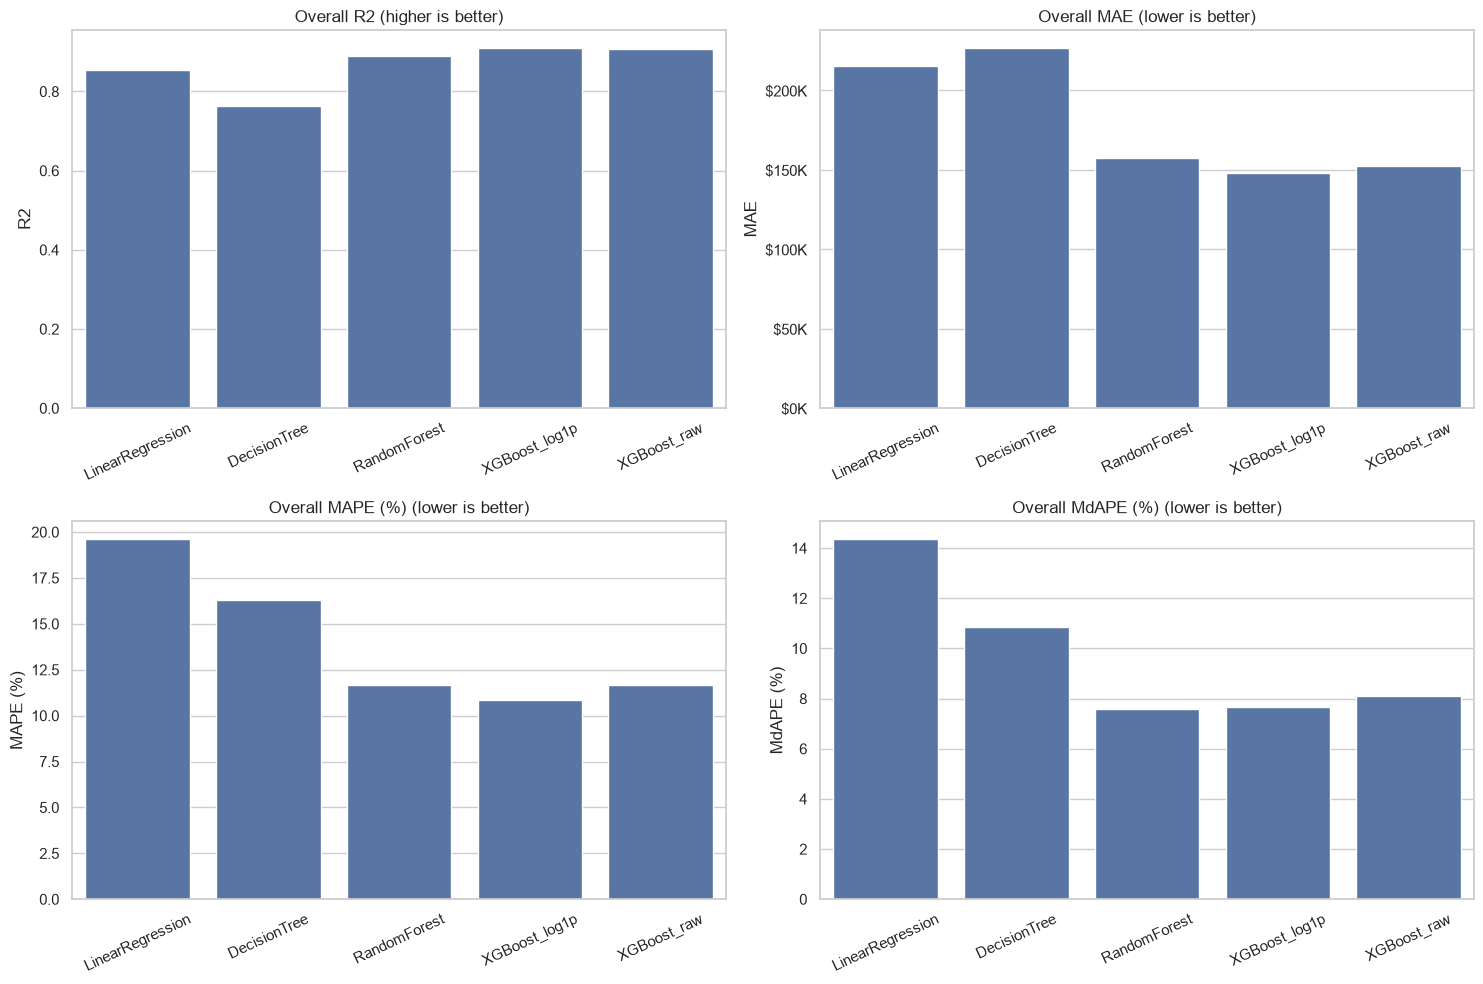

In [11]:
overall_plot_df = overall_summary.copy()
overall_plot_df["model_label"] = pd.Categorical(overall_plot_df["model_label"], categories=model_order, ordered=True)
overall_plot_df = overall_plot_df.sort_values("model_label")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metric_specs = [
    ("r2", "R2", "higher is better"),
    ("mae", "MAE", "lower is better"),
    ("mape", "MAPE (%)", "lower is better"),
    ("mdape", "MdAPE (%)", "lower is better"),
]

for ax, (metric, label, subtitle) in zip(axes.flat, metric_specs):
    sns.barplot(data=overall_plot_df, x="model_label", y=metric, order=model_order, ax=ax)
    ax.set_title(f"Overall {label} ({subtitle})")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.tick_params(axis="x", rotation=25)
    if metric == "mae":
        plot_currency_axis(ax)

save_figure("01_overall_model_comparison.png")
plt.show()


### 9.2 Price Band Performance

These charts show whether each model is more accurate for low-, middle-, or high-price homes. MdAPE is the main selection metric, while MAE shows the dollar impact.


Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/02_price_quintile_error.png


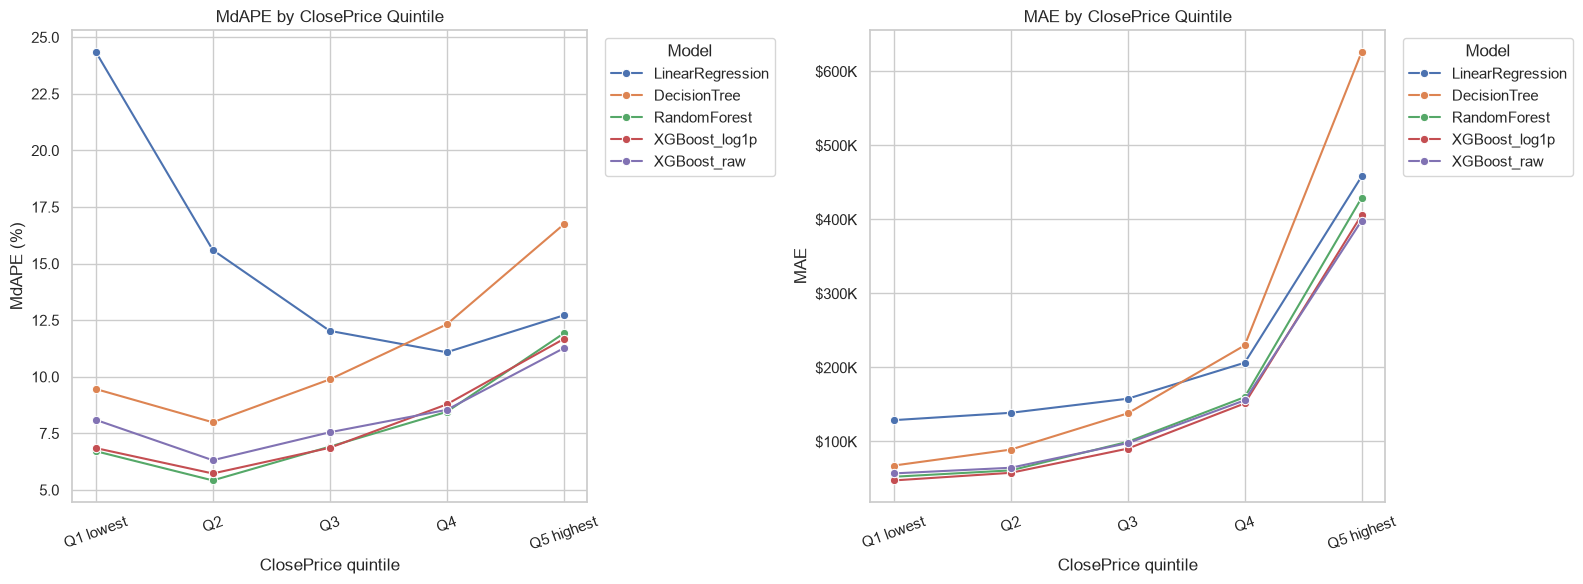

Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/03_price_extreme_mdape.png


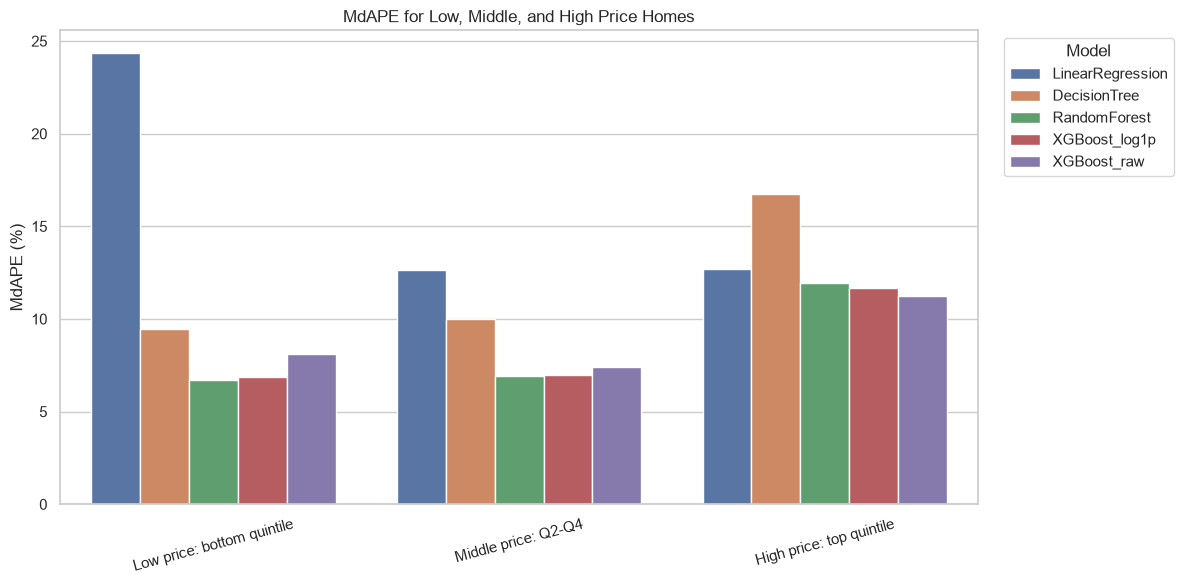

In [12]:
price_quintile_plot = price_band_summary[price_band_summary["segment_type"].eq("ClosePrice_quintile")].copy()
price_quintile_order = ordered_segment_values(price_quintile_plot, "ClosePrice_quintile")
price_quintile_plot["segment_value"] = pd.Categorical(
    price_quintile_plot["segment_value"], categories=price_quintile_order, ordered=True
)
price_quintile_plot["model_label"] = pd.Categorical(price_quintile_plot["model_label"], categories=model_order, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.lineplot(
    data=price_quintile_plot,
    x="segment_value",
    y="mdape",
    hue="model_label",
    hue_order=model_order,
    marker="o",
    ax=axes[0],
)
axes[0].set_title("MdAPE by ClosePrice Quintile")
axes[0].set_xlabel("ClosePrice quintile")
axes[0].set_ylabel("MdAPE (%)")
axes[0].tick_params(axis="x", rotation=20)

sns.lineplot(
    data=price_quintile_plot,
    x="segment_value",
    y="mae",
    hue="model_label",
    hue_order=model_order,
    marker="o",
    ax=axes[1],
)
axes[1].set_title("MAE by ClosePrice Quintile")
axes[1].set_xlabel("ClosePrice quintile")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)
plot_currency_axis(axes[1])

for ax in axes:
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

save_figure("02_price_quintile_error.png")
plt.show()

price_extreme_plot = price_band_summary[price_band_summary["segment_type"].eq("price_extreme_band")].copy()
price_extreme_order = ["Low price: bottom quintile", "Middle price: Q2-Q4", "High price: top quintile"]
price_extreme_plot["segment_value"] = pd.Categorical(
    price_extreme_plot["segment_value"], categories=price_extreme_order, ordered=True
)
price_extreme_plot["model_label"] = pd.Categorical(price_extreme_plot["model_label"], categories=model_order, ordered=True)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=price_extreme_plot,
    x="segment_value",
    y="mdape",
    hue="model_label",
    hue_order=model_order,
)
plt.title("MdAPE for Low, Middle, and High Price Homes")
plt.xlabel("")
plt.ylabel("MdAPE (%)")
plt.xticks(rotation=15)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
save_figure("03_price_extreme_mdape.png")
plt.show()


### 9.3 Geography Error Concentration

For geography, focus on the selected model and show the highest-error segments. This keeps the slide readable and makes it easier to discuss which local markets need better features or more data.


Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/04_top_county_mdape.png


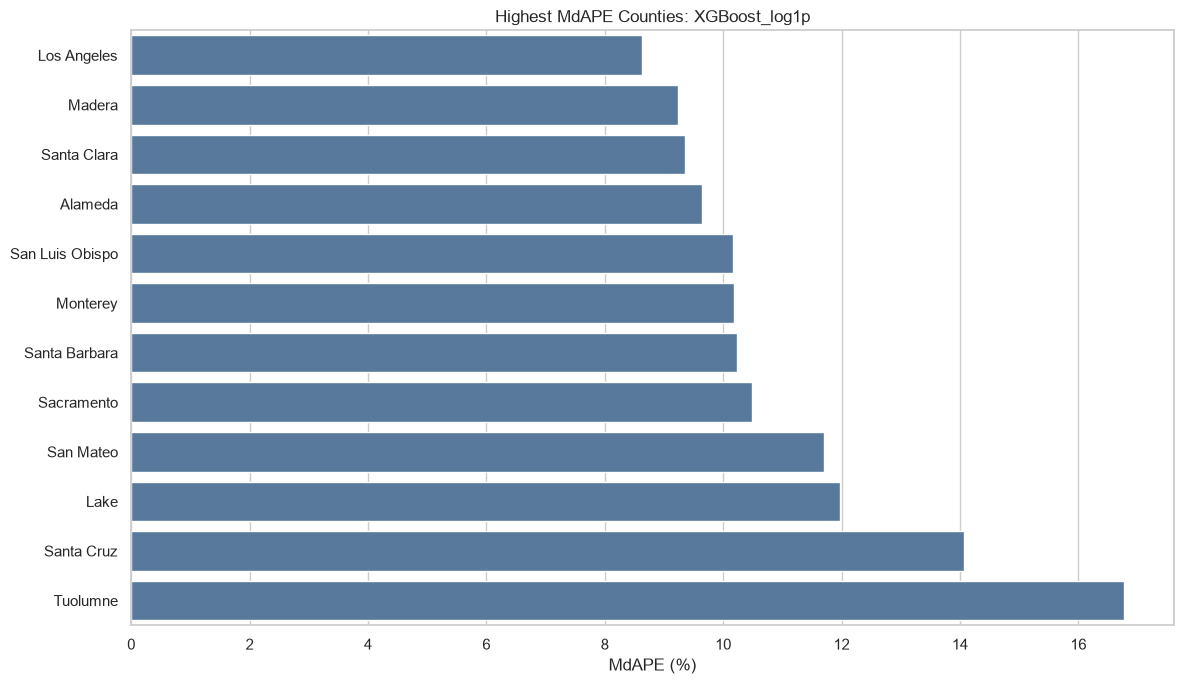

Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/05_top_school_district_mdape.png


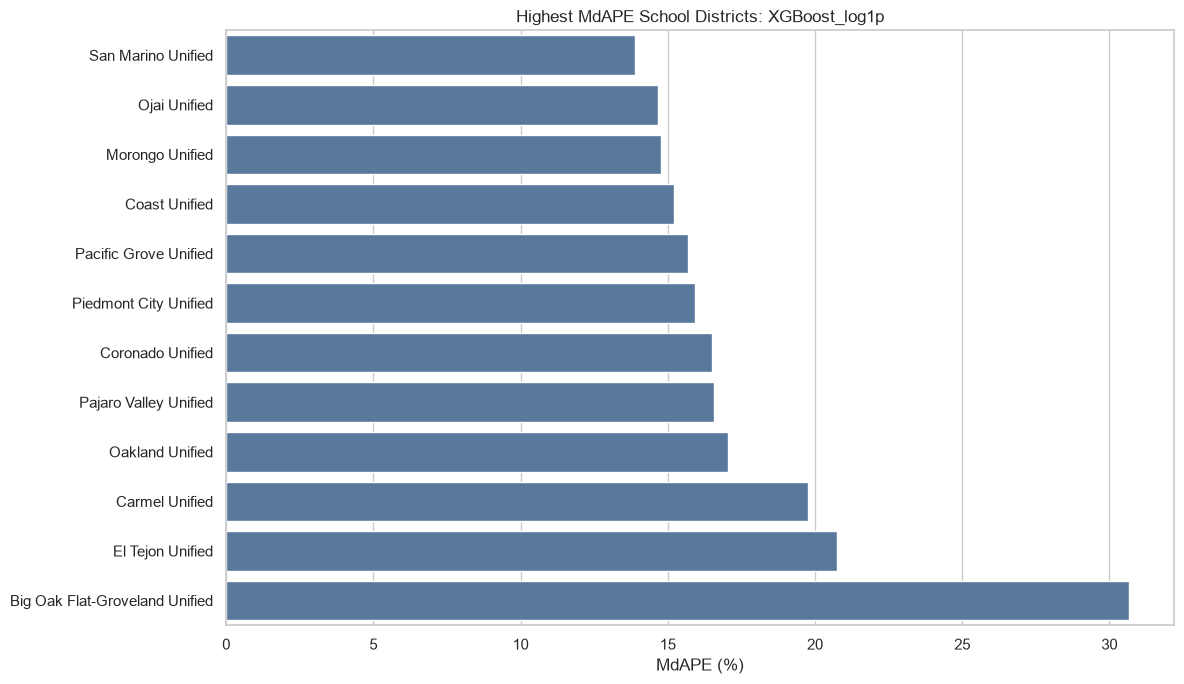

In [13]:
selected_geography_summary = geography_summary[geography_summary["model_label"].eq(presentation_model_label)].copy()

for segment_type, filename, title in [
    ("CountyOrParish", "04_top_county_mdape.png", "Highest MdAPE Counties"),
    ("UnifiedSchoolDistrict", "05_top_school_district_mdape.png", "Highest MdAPE School Districts"),
]:
    plot_df = (
        selected_geography_summary[selected_geography_summary["segment_type"].eq(segment_type)]
        .sort_values("mdape", ascending=False)
        .head(12)
        .sort_values("mdape")
    )
    if plot_df.empty:
        print(f"No rows available for {segment_type}")
        continue

    plt.figure(figsize=(12, 7))
    sns.barplot(data=plot_df, x="mdape", y="segment_value", color="#4C78A8")
    plt.title(f"{title}: {presentation_model_label}")
    plt.xlabel("MdAPE (%)")
    plt.ylabel("")
    save_figure(filename)
    plt.show()


### 9.4 Property Segment and Missingness Patterns

These charts check whether model errors are concentrated in large homes, older homes, or rows with many missing engineered inputs.


Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/07_living_area_mdape.png


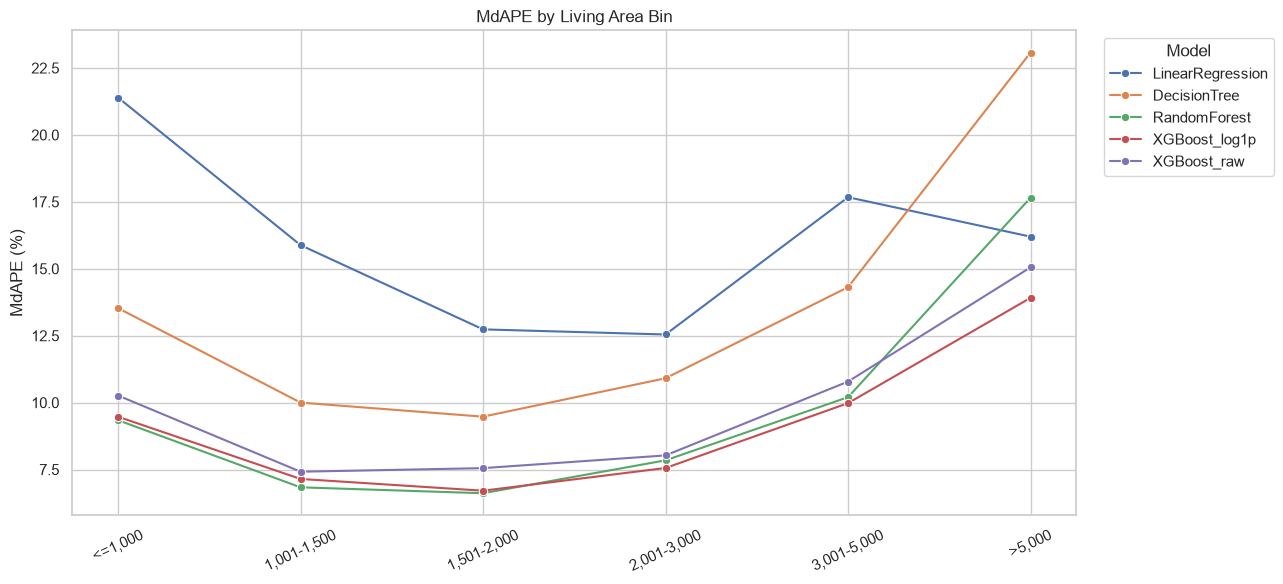

Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/08_property_age_mdape.png


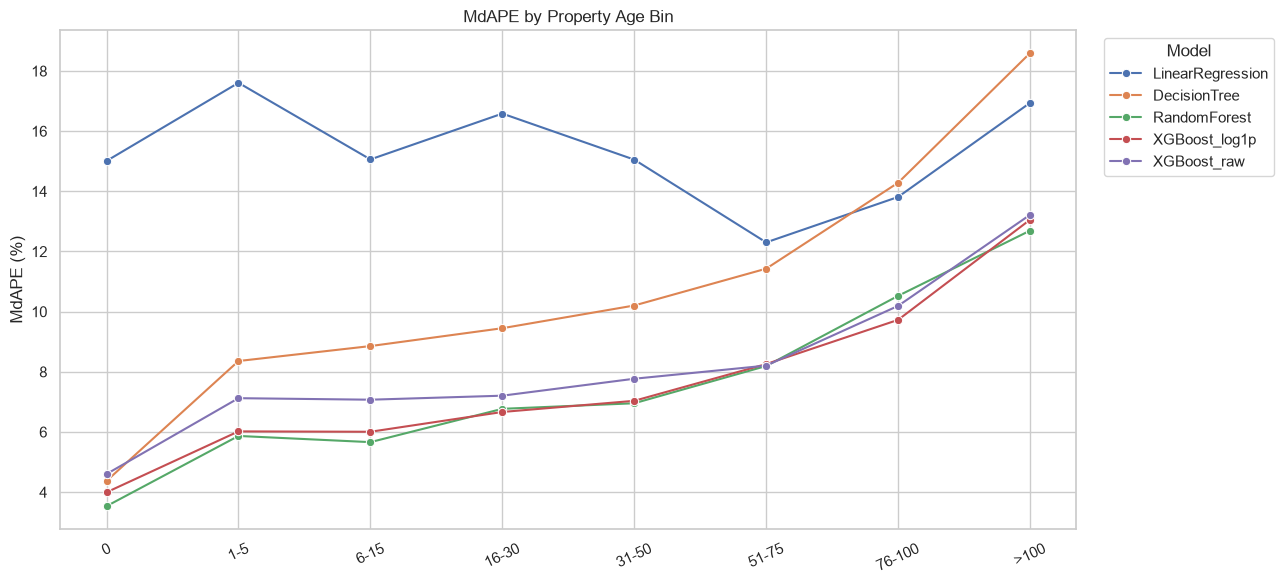

Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/09_missing_feature_count_mdape.png


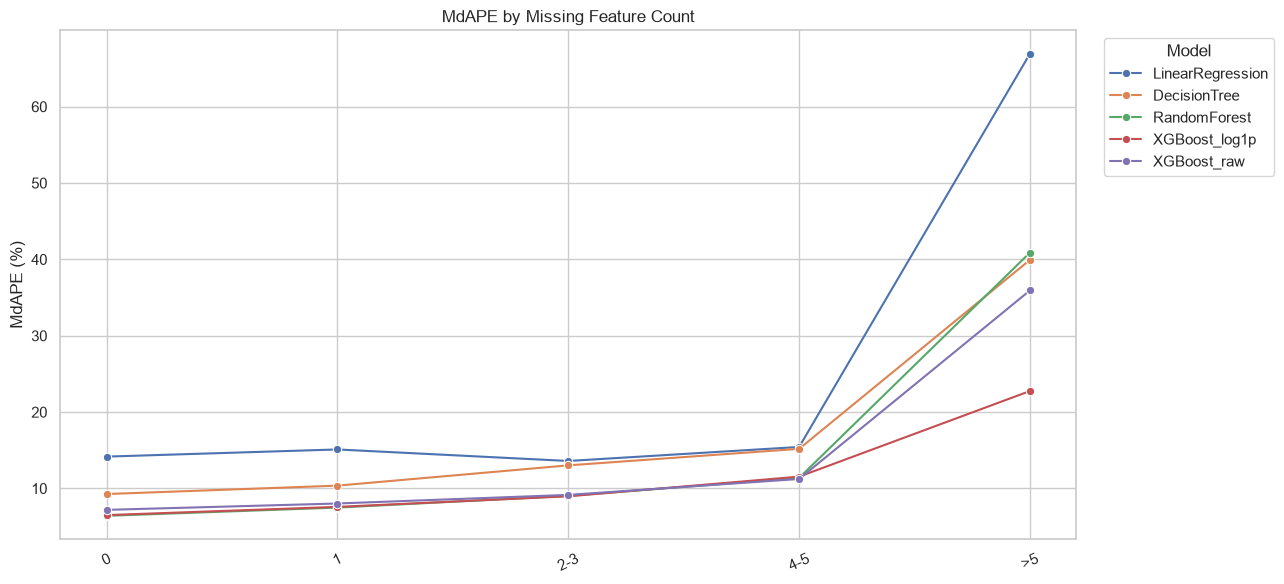

In [14]:
property_plot_df = property_segment_summary.copy()
property_plot_df["model_label"] = pd.Categorical(property_plot_df["model_label"], categories=model_order, ordered=True)

for segment_type, filename, title in [
    ("LivingArea_bin", "07_living_area_mdape.png", "MdAPE by Living Area Bin"),
    ("PropertyAgeYears_bin", "08_property_age_mdape.png", "MdAPE by Property Age Bin"),
    ("missing_feature_count_bin", "09_missing_feature_count_mdape.png", "MdAPE by Missing Feature Count"),
]:
    plot_df = property_plot_df[property_plot_df["segment_type"].eq(segment_type)].copy()
    if plot_df.empty:
        print(f"No rows available for {segment_type}")
        continue
    segment_order = ordered_segment_values(plot_df, segment_type)
    plot_df["segment_value"] = pd.Categorical(plot_df["segment_value"], categories=segment_order, ordered=True)

    plt.figure(figsize=(13, 6))
    sns.lineplot(
        data=plot_df,
        x="segment_value",
        y="mdape",
        hue="model_label",
        hue_order=model_order,
        marker="o",
    )
    plt.title(title)
    plt.xlabel("")
    plt.ylabel("MdAPE (%)")
    plt.xticks(rotation=25)
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    save_figure(filename)
    plt.show()


### 9.5 Underprediction, Overprediction, and Large Error Rows

Use these charts to explain what the selected model gets wrong: whether errors are symmetric, whether extreme rows drive the issue, and whether predictions are pulled toward the middle of the price distribution.


Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/10_selected_model_actual_vs_predicted_and_error_distribution.png


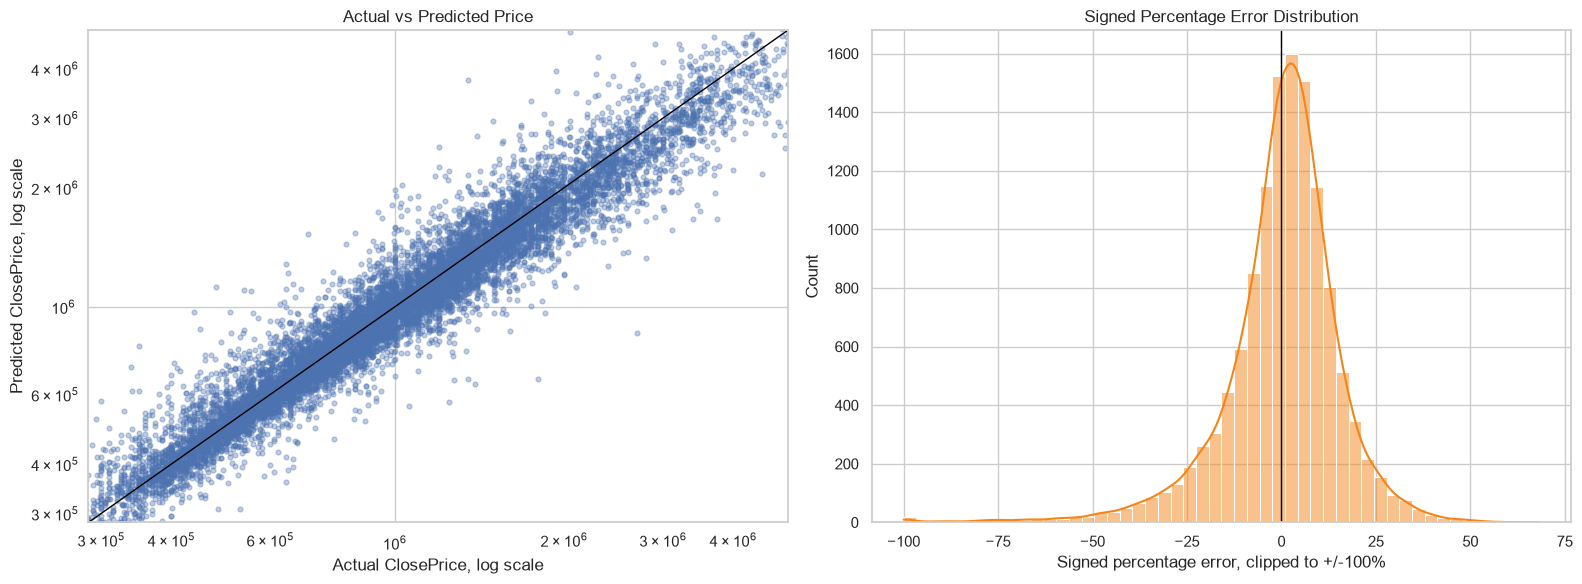

Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/11_large_error_direction.png


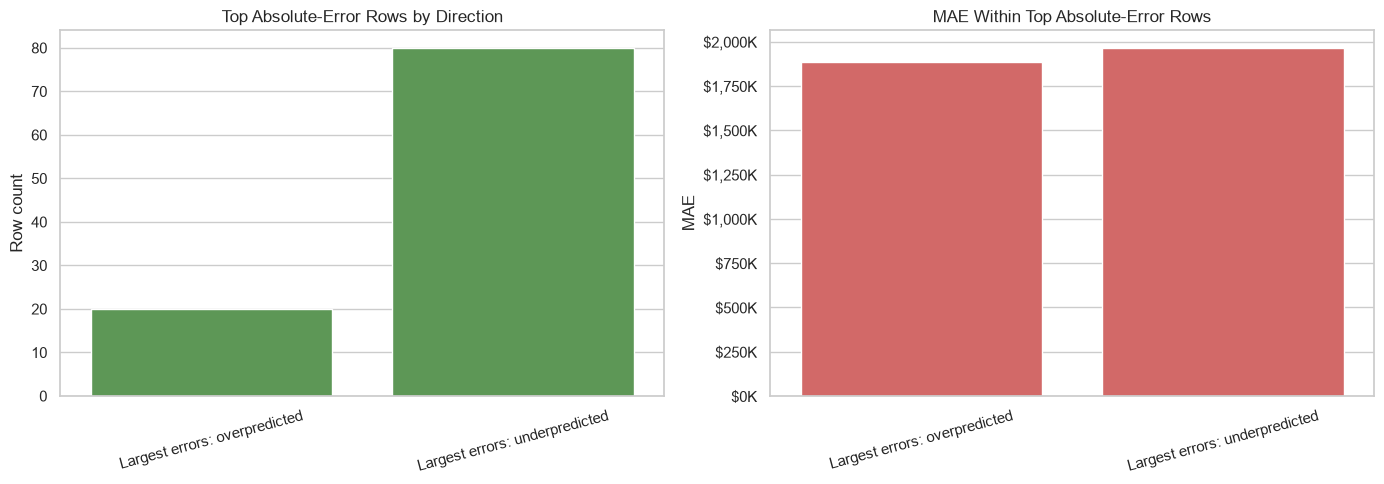

Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/12_top_error_county_mix.png


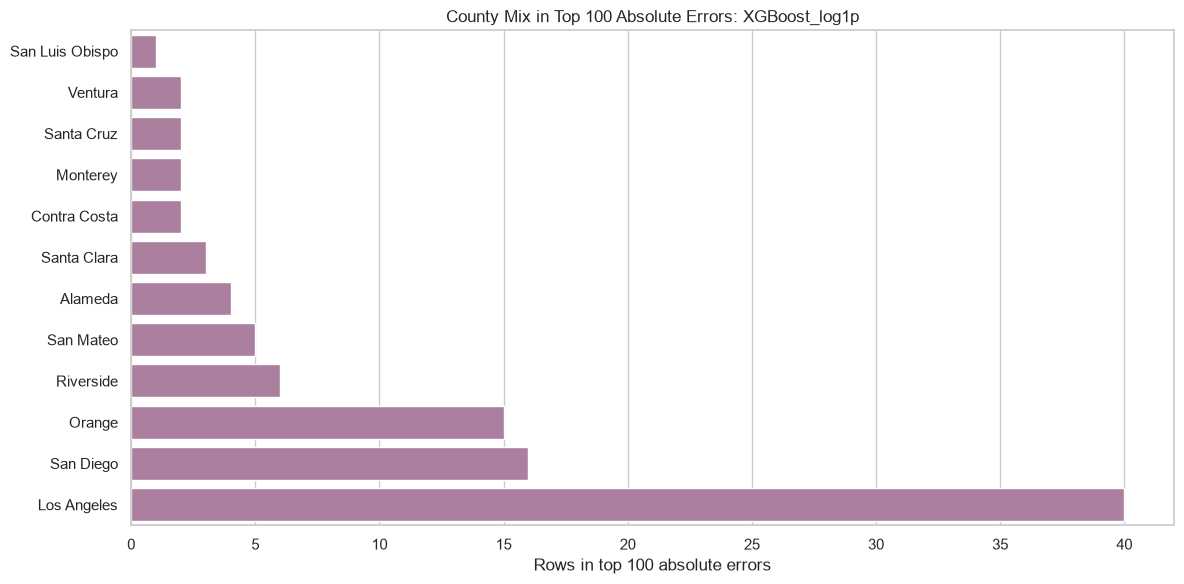

In [15]:
selected_eval_df = evaluation_df[evaluation_df["model_label"].eq(presentation_model_label)].copy()
selected_eval_df = selected_eval_df.dropna(subset=["ClosePrice", "predicted_ClosePrice", "residual", "absolute_percentage_error"])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
price_min = max(1, np.nanpercentile(selected_eval_df[["ClosePrice", "predicted_ClosePrice"]].to_numpy().ravel(), 1))
price_max = np.nanpercentile(selected_eval_df[["ClosePrice", "predicted_ClosePrice"]].to_numpy().ravel(), 99)

axes[0].scatter(
    selected_eval_df["ClosePrice"],
    selected_eval_df["predicted_ClosePrice"],
    s=12,
    alpha=0.35,
)
axes[0].plot([price_min, price_max], [price_min, price_max], color="black", linewidth=1)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlim(price_min, price_max)
axes[0].set_ylim(price_min, price_max)
axes[0].set_title("Actual vs Predicted Price")
axes[0].set_xlabel("Actual ClosePrice, log scale")
axes[0].set_ylabel("Predicted ClosePrice, log scale")

clipped_signed_pct = selected_eval_df["signed_percentage_error"].clip(-100, 100)
sns.histplot(clipped_signed_pct, bins=50, kde=True, ax=axes[1], color="#F58518")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Signed Percentage Error Distribution")
axes[1].set_xlabel("Signed percentage error, clipped to +/-100%")
axes[1].set_ylabel("Count")

save_figure("10_selected_model_actual_vs_predicted_and_error_distribution.png")
plt.show()

large_direction_plot = metrics_summary_df[
    metrics_summary_df["segment_type"].eq("large_error_direction")
    & metrics_summary_df["model_label"].eq(presentation_model_label)
    & ~metrics_summary_df["segment_value"].eq("Not top absolute-error rows")
].copy()

if not large_direction_plot.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.barplot(data=large_direction_plot, x="segment_value", y="count", ax=axes[0], color="#54A24B")
    axes[0].set_title("Top Absolute-Error Rows by Direction")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Row count")
    axes[0].tick_params(axis="x", rotation=15)

    sns.barplot(data=large_direction_plot, x="segment_value", y="mae", ax=axes[1], color="#E45756")
    axes[1].set_title("MAE Within Top Absolute-Error Rows")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("MAE")
    axes[1].tick_params(axis="x", rotation=15)
    plot_currency_axis(axes[1])

    save_figure("11_large_error_direction.png")
    plt.show()
else:
    print("No large-error direction rows available for plotting.")

top_error_selected = selected_eval_df.nlargest(100, "absolute_error").copy()
if not top_error_selected.empty:
    top_error_county = (
        top_error_selected["CountyOrParish"]
        .fillna("Missing")
        .value_counts()
        .head(12)
        .reset_index()
    )
    top_error_county.columns = ["CountyOrParish", "top_100_error_count"]

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_error_county.sort_values("top_100_error_count"), x="top_100_error_count", y="CountyOrParish", color="#B279A2")
    plt.title(f"County Mix in Top 100 Absolute Errors: {presentation_model_label}")
    plt.xlabel("Rows in top 100 absolute errors")
    plt.ylabel("")
    save_figure("12_top_error_county_mix.png")
    plt.show()


### 9.6 Manual Review Flag Summary

This chart summarizes the triage flags among the largest-error rows. It is useful for motivating the next feature-engineering actions.


Saved figure: /Users/soyeonpark/Projects/IDX_internship_2026/idx-california-price-prediction/outputs/week8_evaluation/figures/13_manual_review_flag_summary.png


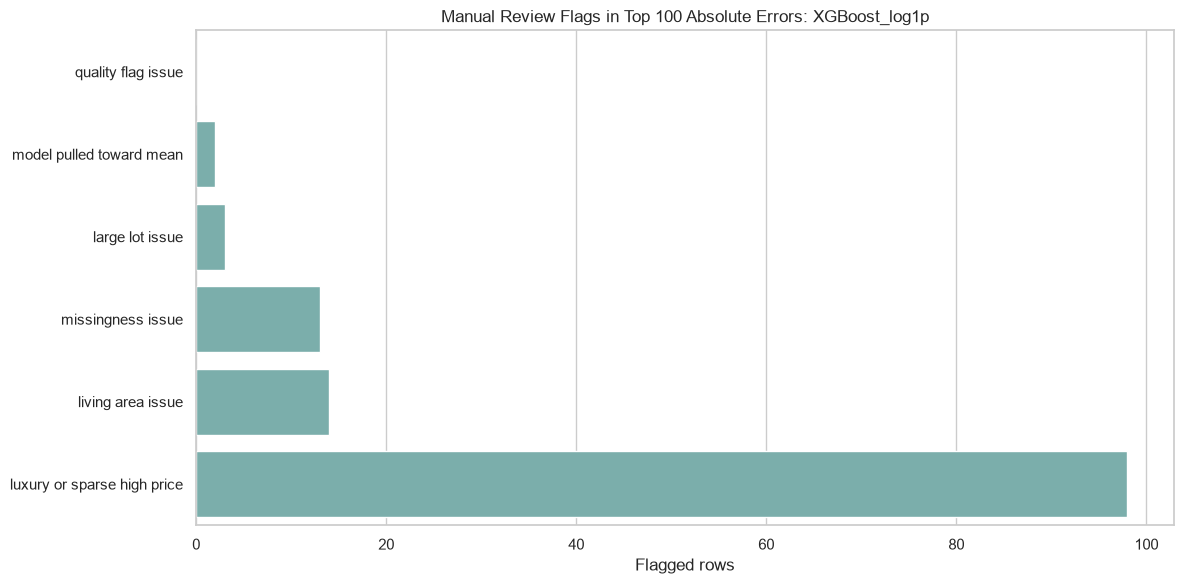

In [16]:
flag_plot_df = flag_summary_df.copy()
flag_plot_df = flag_plot_df[flag_plot_df["model_label"].eq(presentation_model_label)].copy()
flag_plot_df["review_flag"] = flag_plot_df["review_flag"].str.replace("possible_", "", regex=False).str.replace("_", " ")
flag_plot_df = flag_plot_df.sort_values("top_100_flag_count")

if not flag_plot_df.empty:
    plt.figure(figsize=(12, 6))
    sns.barplot(data=flag_plot_df, x="top_100_flag_count", y="review_flag", color="#72B7B2")
    plt.title(f"Manual Review Flags in Top 100 Absolute Errors: {presentation_model_label}")
    plt.xlabel("Flagged rows")
    plt.ylabel("")
    save_figure("13_manual_review_flag_summary.png")
    plt.show()
else:
    print("No manual review flag rows available for plotting.")


## 10. Evaluation Notes

Overall model comparison:
- `XGBoost_log1p` had the best overall R², MAE, RMSE, and MAPE on the June 2026 final test set: R² `0.9087`, MAE `$148,075`, RMSE `$289,276`, and MAPE `10.84%`.
- `RandomForest` had the best overall MdAPE by a very small margin: `7.60%` vs. `7.65%` for `XGBoost_log1p`.
- `XGBoost_log1p` is still the preferred final model because it improves the main dollar-error metrics and keeps percentage error nearly tied with Random Forest.

Price-band insights for `XGBoost_log1p`:
- The model performed best in the middle price bands. Q2-Q4 had MdAPE around `5.73%` to `8.78%`, and the combined middle-price group had MdAPE `6.98%`.
- The lowest-price quintile had low dollar error, with MAE about `$47K`, but percentage error was still noticeable with MdAPE `6.85%`.
- The highest-price quintile was the hardest group: MAE about `$406K`, MAPE `14.18%`, and MdAPE `11.67%`. The mean residual was positive, so high-price homes were underpredicted on average.

Geography insights for `XGBoost_log1p`:
- County-level dollar errors were highest in expensive coastal counties: San Mateo MAE `$320K`, Santa Cruz `$273K`, Santa Clara `$262K`, Monterey `$210K`, and Alameda `$205K`.
- Some lower-volume or more heterogeneous counties also had high percentage error, especially Tuolumne with MdAPE `16.78%` and Santa Cruz with MdAPE `14.08%`.
- Luxury ZIP examples showed concentrated high-dollar error, especially `90265` with MAE about `$1.02M`, `90272` about `$766K`, `90049` about `$713K`, and `92118` about `$672K`.

Property segment insights for `XGBoost_log1p`:
- Larger homes were harder to predict. Homes over 5,000 sqft had MAE about `$791K`, MAPE `19.53%`, and MdAPE `13.91%`.
- Mid-sized homes were much more stable. The 1,501-2,000 sqft group had MdAPE `6.71%`, and the 2,001-3,000 sqft group had MdAPE `7.56%`.
- Very old homes were also more difficult. Homes over 100 years old had MAE about `$218K`, MAPE `16.44%`, and MdAPE `13.06%`.
- Missingness mattered. Rows with 0 missing features had MdAPE `6.51%`, while rows with 4-5 missing features rose to `11.55%`. The `>5` missing group was very small but extremely unstable.

Largest-error row patterns:
- The top 100 absolute-error rows for `XGBoost_log1p` were overwhelmingly high-price homes: 98 of 100 were flagged as possible luxury or sparse high-price cases.
- Among the top 100 errors, 80 were underpredictions and 20 were overpredictions. The underpredicted rows had median actual price around `$5.63M`, which supports the pattern that luxury homes are pulled downward.
- Top-error rows were concentrated in Los Angeles, San Diego, and Orange counties.
- A smaller number of top-error rows also showed possible living-area issues, missingness issues, or large-lot issues, but these were secondary compared with luxury-market scarcity.

Recommended next feature-engineering actions:
- Add stronger luxury-market and neighborhood-level signals, especially for high-price ZIP codes and coastal counties.
- Improve local aggregate features for sparse luxury segments, possibly using broader geography fallback plus luxury-specific indicators.
- Add or improve amenity/detail features that can distinguish luxury homes from ordinary high-square-footage homes.
- Continue numeric sanity checks for unusual living area and lot size rows, but do not treat those as the main error source.
